<b>Tangente, Kurt Clarence J.</b><br>
T09-A<br>
2/23/2025

In [105]:
!pip install pandas numpy matplotlib scipy statsmodels --upgrade

In [106]:
# imports and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestPower

In [107]:
# load dataset
df = pd.read_csv(r"C:\Users\kurtt\OneDrive\Documents\datasets\student_lifestyle_dataset.csv", delimiter=",")
df

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High
...,...,...,...,...,...,...,...,...
1995,1996,6.5,0.2,7.4,2.1,7.8,3.32,Moderate
1996,1997,6.3,2.8,8.8,1.5,4.6,2.65,Moderate
1997,1998,6.2,0.0,6.2,0.8,10.8,3.14,Moderate
1998,1999,8.1,0.7,7.6,3.5,4.1,3.04,High


In [108]:
# summary of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   object 
dtypes: float64(6), int64(1), object(1)
memory usage: 125.1+ KB


In [109]:
# summary of statistics
df.describe()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,7.475800,1.990100,7.501250,2.704550,4.32830,3.115960
std,577.494589,1.423888,1.155855,1.460949,1.688514,2.51411,0.298674
min,1.000000,5.000000,0.000000,5.000000,0.000000,0.00000,2.240000
25%,500.750000,6.300000,1.000000,6.200000,1.200000,2.40000,2.900000
50%,1000.500000,7.400000,2.000000,7.500000,2.600000,4.10000,3.110000
75%,1500.250000,8.700000,3.000000,8.800000,4.100000,6.10000,3.330000
max,2000.000000,10.000000,4.000000,10.000000,6.000000,13.00000,4.000000


In [175]:
# variables for analysis
df[cols].describe().loc[["count","mean","std","25%","50%","75%","max"]]

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,GPA
count,50.000000,50.000000,50.000000
mean,7.442000,2.284000,3.114800
std,1.296949,1.177226,0.291409
25%,6.325000,1.325000,2.942500
50%,7.350000,2.600000,3.110000
75%,8.400000,3.275000,3.262500
max,10.000000,4.000000,3.810000


In [176]:
# CLT sampling (max 50)
df = df.sample(n=50, random_state=1)
df

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
442,443,9.1,3.8,9.1,0.0,2.0,3.27,High
375,376,6.5,3.8,6.3,2.6,4.8,2.62,Moderate
654,655,6.6,2.6,6.2,0.1,8.5,3.11,Moderate
1701,1702,9.3,3.7,6.5,3.9,0.6,3.24,High
186,187,5.2,1.0,8.0,0.3,9.5,3.29,Low
868,869,5.9,2.1,6.1,1.7,8.2,3.13,Low
1044,1045,8.9,3.4,9.2,0.9,1.6,3.11,High
1496,1497,5.6,0.1,6.5,4.2,7.6,2.71,Low
1131,1132,8.9,2.7,8.1,3.8,0.5,3.14,High
1068,1069,9.6,2.6,6.6,2.7,2.5,3.37,High


In [177]:
# summary statistics for selected variables
df[cols].describe().loc[
    ["count","mean","std","25%","50%","75%","max"]
]

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,GPA
count,50.000000,50.000000,50.000000
mean,7.442000,2.284000,3.114800
std,1.296949,1.177226,0.291409
25%,6.325000,1.325000,2.942500
50%,7.350000,2.600000,3.110000
75%,8.400000,3.275000,3.262500
max,10.000000,4.000000,3.810000


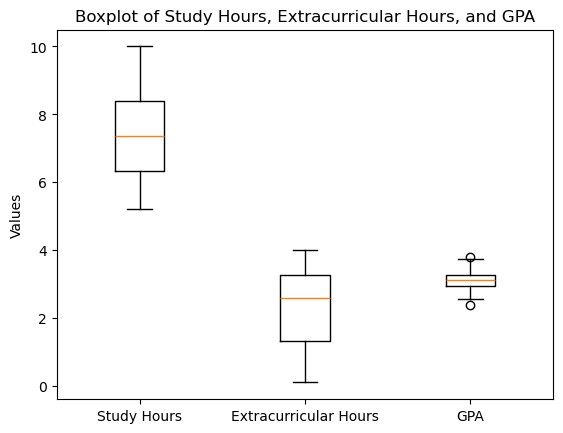

In [178]:
# boxplot to visualize outliers for key variables
plt.boxplot(
    df[[
        "Study_Hours_Per_Day",
        "Extracurricular_Hours_Per_Day",
        "GPA"
    ]],
    tick_labels=[
        "Study Hours",
        "Extracurricular Hours",
        "GPA"
    ]
)

plt.title("Boxplot of Study Hours, Extracurricular Hours, and GPA")
plt.ylabel("Values")
plt.show()

In [179]:
# detect outliers using 3-sigma rule for key variables
important_cols = [
    "Study_Hours_Per_Day",
    "Extracurricular_Hours_Per_Day",
    "GPA"
]

for col in important_cols:
    z = np.abs(stats.zscore(df[col]))
    print(col, "outliers:", (z > 3).sum())

Study_Hours_Per_Day outliers: 0
Extracurricular_Hours_Per_Day outliers: 0
GPA outliers: 0


C:\Users\kurtt\AppData\Local\Temp\ipykernel_7080\960103211.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


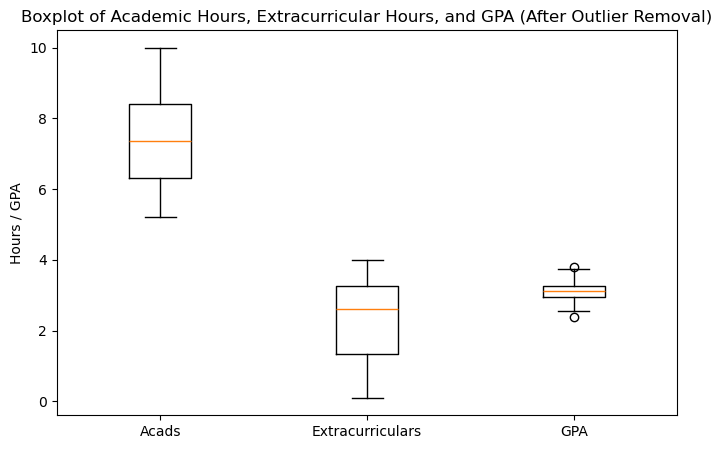

In [180]:
# boxplot after outlier removal
cols = [
    "Study_Hours_Per_Day",
    "Extracurricular_Hours_Per_Day",
    "GPA"
]

plt.figure(figsize=(8,5))

plt.boxplot(
    df[cols].values,
    labels=["Acads", "Extracurriculars", "GPA"]
)

plt.title("Boxplot of Academic Hours, Extracurricular Hours, and GPA (After Outlier Removal)")
plt.ylabel("Hours / GPA")

plt.show()

In [181]:
# normality test (Shapiro-Wilk)

cols = ["Study_Hours_Per_Day", "Extracurricular_Hours_Per_Day", "GPA"]

for col in cols:
    stat, p = stats.shapiro(df[col])
    
    print(col)
    print("Statistic:", stat)
    print("p-value:", p)
    
    if p > 0.05:
        print(f"Conclusion: {col} is normally distributed.\n")
    else:
        print(f"Conclusion: {col} is not normally distributed.\n")

Study_Hours_Per_Day
Statistic: 0.9607460873903498
p-value: 0.09553018645506003
Conclusion: Study_Hours_Per_Day is normally distributed.

Extracurricular_Hours_Per_Day
Statistic: 0.9213973274568413
p-value: 0.002649674781686253
Conclusion: Extracurricular_Hours_Per_Day is not normally distributed.

GPA
Statistic: 0.9864868489900634
p-value: 0.8331687373787724
Conclusion: GPA is normally distributed.



In [182]:
# F-test (variance comparison between study and extracurricular)

var1 = np.var(df["Study_Hours_Per_Day"], ddof=1)
var2 = np.var(df["Extracurricular_Hours_Per_Day"], ddof=1)

# make sure F >= 1
if var1 > var2:
    f_stat = var1 / var2
    df1 = len(df["Study_Hours_Per_Day"]) - 1
    df2 = len(df["Extracurricular_Hours_Per_Day"]) - 1
else:
    f_stat = var2 / var1
    df1 = len(df["Extracurricular_Hours_Per_Day"]) - 1
    df2 = len(df["Study_Hours_Per_Day"]) - 1

# two-tailed p-value
p_value = 2 * min(stats.f.cdf(f_stat, df1, df2), 1 - stats.f.cdf(f_stat, df1, df2))

print("F-statistic:", f_stat)
print("p-value:", p_value)

# conclusion
alpha = 0.05
if p_value < alpha:
    print("Conclusion: The variances are significantly different.")
else:
    print("Conclusion: The variances are equal (no significant difference).")

F-statistic: 1.213741694547854
p-value: 0.5003086770101479
Conclusion: The variances are equal (no significant difference).


In [183]:
# paired t-test
t_stat, p_val = stats.ttest_rel(
    df["Study_Hours_Per_Day"],
    df["Extracurricular_Hours_Per_Day"]
)

print("t-statistic:", t_stat)
print("p-value:", p_val)

# conclusion
if p_val < 0.05:
    print("Conclusion: Students spend more time on study hours than on extracurricular hours, "
          "and this difference is statistically significant.")
else:
    print("Conclusion: There is no statistically significant difference between study hours "
          "and extracurricular hours.")

t-statistic: 23.840597167551017
p-value: 1.2978387229447978e-28
Conclusion: Students spend more time on study hours than on extracurricular hours, and this difference is statistically significant.


In [184]:
# Cohen's d
mean1 = df["Study_Hours_Per_Day"].mean()
mean2 = df["Extracurricular_Hours_Per_Day"].mean()

std1 = df["Study_Hours_Per_Day"].std(ddof=1)
std2 = df["Extracurricular_Hours_Per_Day"].std(ddof=1)

pooled_std = np.sqrt((std1**2 + std2**2) / 2)

cohens_d = (mean1 - mean2) / pooled_std

# power of the test
analysis = TTestPower()
power = analysis.power(
    effect_size=abs(cohens_d),
    nobs=len(df),
    alpha=0.05
)

print("Cohen's d:", cohens_d)
print("Power of the Test: {:.2f}%".format(power * 100))

Cohen's d: 4.164597090654234
Power of the Test: 100.00%
